# Image Denoising with a Convolutional Autoencoder

A convolutional **autoencoder** trained to remove noise from images of the CIFAR-10 dataset. The network learns to compress a noisy image into a compact representation and reconstruct a clean version from it.

**Techniques:** encoder–decoder architecture, Conv2D / MaxPooling / UpSampling, synthetic noise injection, image reconstruction (MSE loss).

### 1. Imports

In [ ]:
#%tensorflow_version 2.x
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt


### 2. Load CIFAR-10 and normalise pixel values

In [ ]:
# Load CIFAR10 Data
(x_train, _), (x_test, _) = cifar10.load_data()

# Data Preprocessing
x_train = x_train / 255
x_test = x_test / 255
print("reading done")
print(x_train.shape)

reading done
(50000, 32, 32, 3)


In [ ]:
noise_factor = 0.05
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


### 3. Add noise and visualise
We add Gaussian noise to the images: the noisy versions are the model input, the originals are the target it must reconstruct.

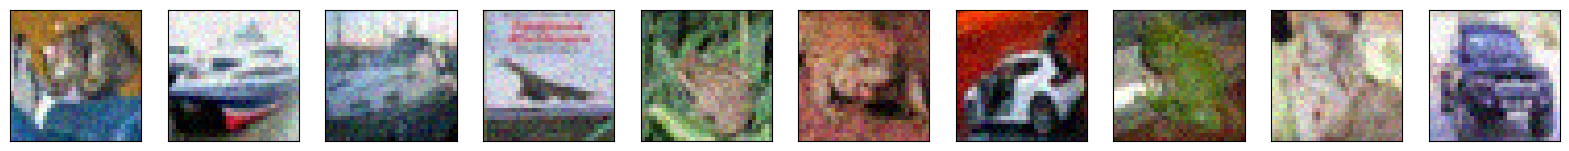

In [ ]:
# Display some noisy images
n = 10
plt.figure(figsize=(20, 2))
for i in range(n):
    ax = plt.subplot(1, n, i+1)
    plt.imshow(x_test_noisy[i])
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

### 4. Autoencoder architecture
The **encoder** downsamples the image into a compact latent representation; the **decoder** upsamples it back to the original size and reconstructs the denoised image.

In [ ]:
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
input_img = Input(shape=(32, 32, 3))


x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# at this point the representation is (7, 7, 32)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # Adapt for color channels (3)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')  # Use mean squared error for continuous values
autoencoder.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 32)          0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 8, 8, 32)          9248  

### 5. Train the model

In [ ]:
 autoencoder.fit(x_train_noisy, x_train,
                epochs=150,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))


Epoch 1/150
391/391 [==============================] - 10s 14ms/step - loss: 0.0124 - val_loss: 0.0070
Epoch 2/150
391/391 [==============================] - 4s 9ms/step - loss: 0.0062 - val_loss: 0.0056
Epoch 3/150
391/391 [==============================] - 4s 9ms/step - loss: 0.0055 - val_loss: 0.0051
Epoch 4/150
391/391 [==============================] - 4s 10ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 5/150
391/391 [==============================] - 4s 9ms/step - loss: 0.0047 - val_loss: 0.0045
Epoch 6/150
391/391 [==============================] - 4s 9ms/step - loss: 0.0045 - val_loss: 0.0043
Epoch 7/150
391/391 [==============================] - 4s 11ms/step - loss: 0.0043 - val_loss: 0.0046
Epoch 8/150
391/391 [==============================] - 4s 11ms/step - loss: 0.0041 - val_loss: 0.0042
Epoch 9/150
391/391 [==============================] - 4s 9ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 10/150
391/391 [==============================] - 4s 10ms/step - loss: 0.0039 - 

### 6. Results
Top row: noisy inputs. Bottom row: the images reconstructed (denoised) by the autoencoder.

313/313 [==============================] - 1s 2ms/step


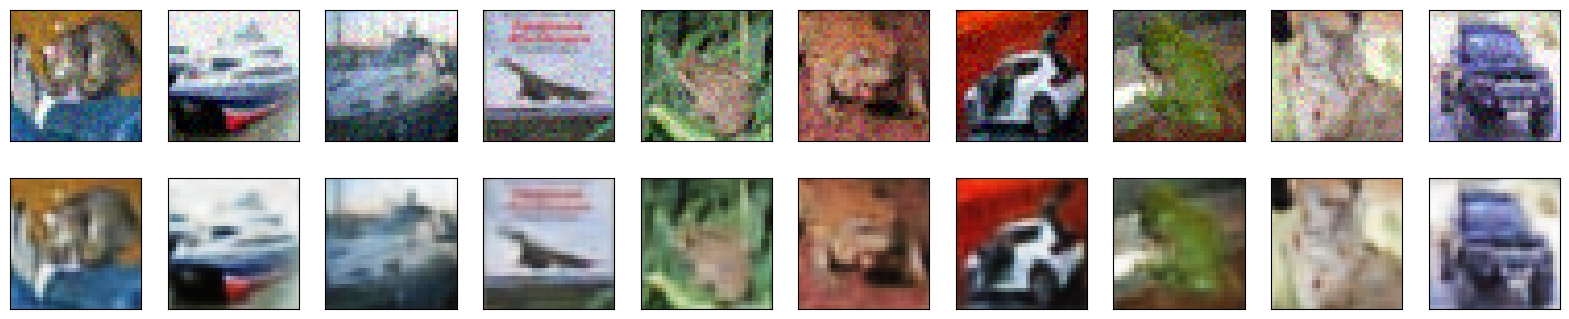

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
  # display original
  ax = plt.subplot(2, n, i+1)
  plt.imshow(x_test_noisy[i])
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # display reconstruction
  ax = plt.subplot(2, n, i + n+1)
  plt.imshow(decoded_imgs[i])
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()